In [1]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Load datase
df = pd.read_csv("xAPI-Edu-Data.csv")

In [3]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [5]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [6]:
# Extract numerical features only
# Rows = Students (Samples)
# Columns = Features
numerical_features=(df[["raisedhands","VisITedResources","AnnouncementsView","Discussion"]])


In [7]:
numerical_features = np.array(numerical_features)
print("Matrex",numerical_features)
print("Dimensions",numerical_features.ndim)
print("Sahpe",numerical_features.shape)

Matrex [[15 16  2 20]
 [20 20  3 25]
 [10  7  0 30]
 ...
 [55 74 25 29]
 [30 17 14 57]
 [35 14 23 62]]
Dimensions 2
Sahpe (480, 4)


In [8]:
#Scaler
print("Scaler",numerical_features[0,0])


Scaler 15


In [9]:
#Row vector
print("One row vector",numerical_features[0])
print("Dimensions",numerical_features[0].ndim)
print("Sahpe",numerical_features[0].shape)


One row vector [15 16  2 20]
Dimensions 1
Sahpe (4,)


In [10]:
#Column vector
print("One column vector",numerical_features[:,0])
print("Dimensions",numerical_features[:,0].ndim)
print("Sahpe",numerical_features[:,0].shape)

One column vector [ 15  20  10  30  40  42  35  50  12  70  50  19   5  20  62  30  36  55
  69  70  60  10  15   2   0   8  19  25  75  30  35   4   2   8  12  10
   8  45   0  50  14  19  10  30  33  20   7  70  13  29  20  39  55  49
  12  16  19   5  28  27  21  50  80  17   0  13  25  65  70  39  22  29
  11  19  12  50  15  20  13  80   8   8   7   7  50   1  70  19   3   5
   4  80  50  55  80 100  14   6  10  50  50  70   2   1   0   0  12  70
   7  90  70  77   2  25  11   0  77  25  24  60  21   0  66  70   0  12
   2  55  12  70   7  80   0  12  80  70  70  60 100 100  10  19  10  80
  10  70 100  10  60 100  80  23 100  10  70  70  70  70  22  62  82  72
  70  60  55  72  51  80  60  30  40  60  20  20  50  10  60  15  80  40
  60  50  85  25  10  87  85  80  75  85  23  15  95  81  53  15  92  83
  27  45  15  45  25  22  29  72  67  17  27  70  27  17  87   7  17   5
  27  87  96  57  77  80  62  72  87  72   2   5  73   5  51   9  19  32
  32  12  52  72  72  92  72  72 

In [11]:
T = numerical_features.reshape(480, 4, 1)
print("Tensor shape",T.shape)
print("Tensor Dimensions",T.ndim)

Tensor shape (480, 4, 1)
Tensor Dimensions 3


###In machine learning, datasets are stored as matrices where rows represent samples and columns represent features.

# Part 2: ML

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, precision_score, classification_report, ConfusionMatrixDisplay

In [13]:
# Separate target
y = df["Class"]
X = df.drop("Class", axis=1)

# Encode categorical features
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Encode target
y = le.fit_transform(y)

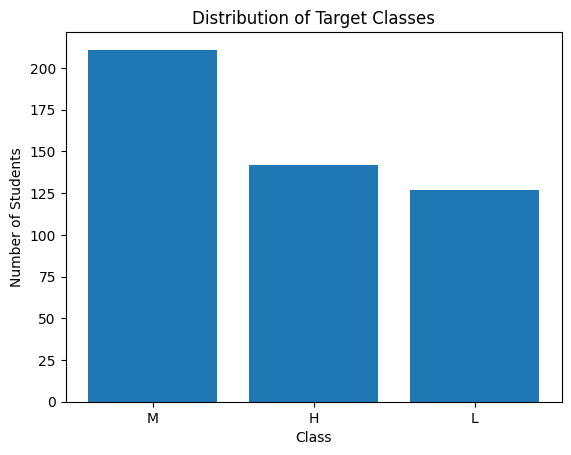

In [14]:
# Count target values
class_counts = df["Class"].value_counts()

# Plot distribution
plt.figure()
plt.bar(class_counts.index, class_counts.values)

plt.xlabel("Class")
plt.ylabel("Number of Students")
plt.title("Distribution of Target Classes")

plt.show()

In [15]:
df["Class"].value_counts(normalize=True)

,proportion
Class,
M,0.439583
H,0.295833
L,0.264583


In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)  # Evaluate accuracy
f_score = f1_score(y_test, y_pred, average='macro')# Evaluate f1_score
recall = recall_score(y_test, y_pred,average='macro')
precision = precision_score(y_test, y_pred,average='macro')
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy}\n")
print(f"F1 Score: {f_score}\n")
print(f"recall: {recall}\n")
print(f"precision: {precision}\n")
print(f"Classification Report: \n{class_report}")

Accuracy: 0.84375

F1 Score: 0.8405639421551294

recall: 0.8430458430458431

precision: 0.8392434988179668

Classification Report: 
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        22
           1       0.86      0.92      0.89        26
           2       0.85      0.83      0.84        48

    accuracy                           0.84        96
   macro avg       0.84      0.84      0.84        96
weighted avg       0.84      0.84      0.84        96



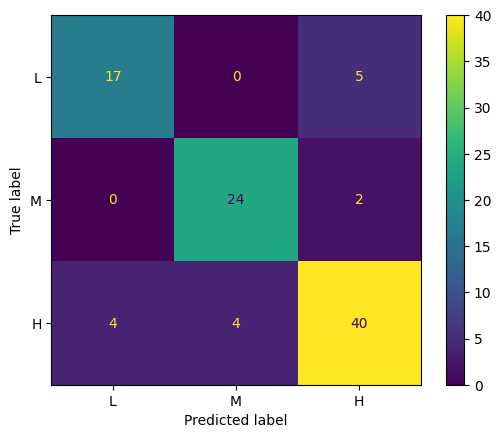

In [18]:
conf_matrix = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["L", "M", "H"])
cm_display.plot()
plt.show()